# Healthcare & Decision Tree Classification
## Pima Indians Diabetes Dataset
**Objective:** Perform exploratory data analysis (EDA), data cleaning, and build a Decision Tree classifier to predict diabetes diagnosis.

**Dataset:** Pima Indians Diabetes Database (Kaggle)  


---
## 1. Import Libraries <a id='1'></a>

In [1]:
# Core
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.impute import SimpleImputer

# Style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('All libraries imported successfully!')

All libraries imported successfully!


---
## 2. Load Dataset <a id='2'></a>

In [2]:
# Load dataset from local CSV
df = pd.read_csv("diabetes.csv")

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)


Dataset loaded successfully!
Shape: 768 rows × 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [3]:
# Validate columns
print(df.columns)

# Fix invalid zeros
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols] = df[cols].replace(0, np.nan)

# Median imputation (column-wise)
for col in cols:
    df[col].fillna(df[col].median(), inplace=True)

# Column descriptions
column_info = {
    'Pregnancies': 'Number of times pregnant',
    'Glucose': 'Plasma glucose concentration (2h oral glucose tolerance test)',
    'BloodPressure': 'Diastolic blood pressure (mm Hg)',
    'SkinThickness': 'Triceps skin fold thickness (mm)',
    'Insulin': '2-Hour serum insulin (mu U/ml)',
    'BMI': 'Body mass index (weight in kg / height in m²)',
    'DiabetesPedigreeFunction': 'Diabetes pedigree function (genetic risk)',
    'Age': 'Age (years)',
    'Outcome': 'Class variable — 1: Diabetic, 0: Non-Diabetic'
}

desc_df = pd.DataFrame(list(column_info.items()), columns=['Feature', 'Description'])
desc_df

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


,Feature,Description
0,Pregnancies,Number of times pregnant
1,Glucose,Plasma glucose concentration (2h oral glucose ...
2,BloodPressure,Diastolic blood pressure (mm Hg)
3,SkinThickness,Triceps skin fold thickness (mm)
4,Insulin,2-Hour serum insulin (mu U/ml)
5,BMI,Body mass index (weight in kg / height in m²)
6,DiabetesPedigreeFunction,Diabetes pedigree function (genetic risk)
7,Age,Age (years)
8,Outcome,"Class variable — 1: Diabetic, 0: Non-Diabetic"


---
## 3. Initial Data Exploration <a id='3'></a>

In [5]:
# Basic info
print('═'*50)
print('  DATASET INFO')
print('═'*50)
df.info()

══════════════════════════════════════════════════
  DATASET INFO
══════════════════════════════════════════════════
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [6]:
# Statistical summary
print('Statistical Summary:')
df.describe().round(2)

Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,121.66,72.39,29.11,140.67,32.46,0.47,33.24,0.35
std,3.37,30.44,12.10,8.79,86.38,6.88,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,14.00,18.20,0.08,21.00,0.00
25%,1.00,99.75,64.00,25.00,121.50,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,29.00,125.00,32.30,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [7]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Missing Values:')
print(missing_df)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing Values:
                          Missing Count  Missing %
Pregnancies                           0        0.0
Glucose                               0        0.0
BloodPressure                         0        0.0
SkinThickness                         0        0.0
Insulin                               0        0.0
BMI                                   0        0.0
DiabetesPedigreeFunction              0        0.0
Age                                   0        0.0
Outcome                               0        0.0

Total missing values: 0


In [8]:
# Class distribution
print('Target Class Distribution:')
outcome_counts = df['Outcome'].value_counts()
print(outcome_counts)
print(f"\nClass ratio — Diabetic: {outcome_counts[1]/len(df)*100:.1f}%  |  Non-Diabetic: {outcome_counts[0]/len(df)*100:.1f}%")

Target Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Class ratio — Diabetic: 34.9%  |  Non-Diabetic: 65.1%


---
## 4. Data Cleaning <a id='4'></a>

> **Key Observation:** Several features contain `0` as values which are **biologically impossible**. For example, a person cannot have `0` Glucose, `0` Blood Pressure, or `0` BMI. These zeros represent **missing/unreported values** and must be treated accordingly.

Biologically Impossible Zero Values:
               Zero Count  Zero %
Glucose                 0     0.0
BloodPressure           0     0.0
SkinThickness           0     0.0
Insulin                 0     0.0
BMI                     0     0.0


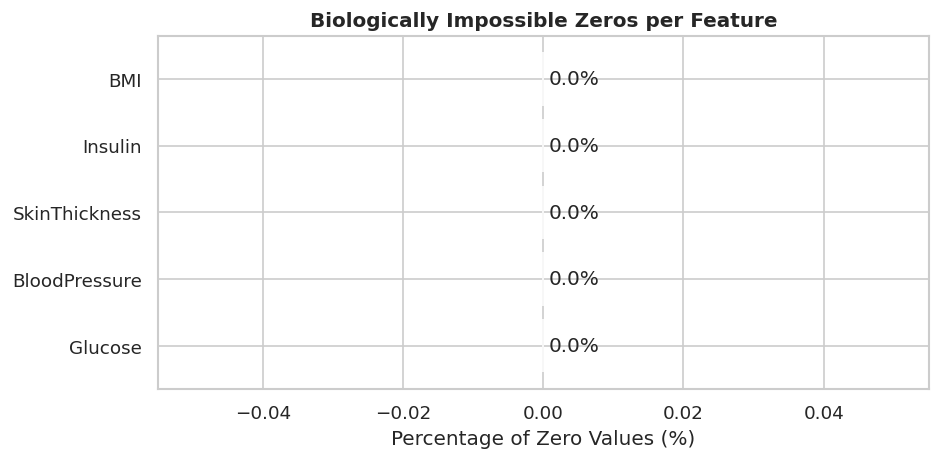

In [9]:
# Identify zero-value counts for medically impossible features
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_counts = pd.DataFrame({
    'Zero Count': [(df[col] == 0).sum() for col in zero_cols],
    'Zero %':     [(df[col] == 0).sum() / len(df) * 100 for col in zero_cols]
}, index=zero_cols).round(2)

print('Biologically Impossible Zero Values:')
print(zero_counts)

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(zero_counts.index, zero_counts['Zero %'], color=sns.color_palette('Set2'))
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_xlabel('Percentage of Zero Values (%)')
ax.set_title('Biologically Impossible Zeros per Feature', fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Replace zeros with NaN for medically impossible features
df_clean = df.copy()
df_clean[zero_cols] = df_clean[zero_cols].replace(0, np.nan)

print(f'Zeros replaced with NaN in: {zero_cols}')
print(f'\nMissing values after replacement:')
print(df_clean.isnull().sum())

Zeros replaced with NaN in: ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

Missing values after replacement:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [11]:
# Impute missing values using MEDIAN (robust to outliers in medical data)
imputer = SimpleImputer(strategy='median')
df_clean[zero_cols] = imputer.fit_transform(df_clean[zero_cols])

# Verify no missing values remain
print('Missing values after imputation:')
print(df_clean.isnull().sum())
print(f'\n✅ Dataset is clean — {df_clean.shape[0]} rows × {df_clean.shape[1]} columns')

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

✅ Dataset is clean — 768 rows × 9 columns


In [12]:
# Check for duplicates
dupes = df_clean.duplicated().sum()
print(f'Duplicate rows: {dupes}')
if dupes > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'Duplicates removed. New shape: {df_clean.shape}')
else:
    print('✅ No duplicate rows found.')

Duplicate rows: 0
✅ No duplicate rows found.


In [13]:
# Outlier detection using IQR method
features = [c for c in df_clean.columns if c != 'Outcome']

outlier_summary = []
for col in features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_summary.append({'Feature': col, 'Outlier Count': n_out, 'Outlier %': round(n_out/len(df_clean)*100, 2)})

outlier_df = pd.DataFrame(outlier_summary)
print('Outlier Summary (IQR method):')
print(outlier_df.to_string(index=False))
print('\nNote: Outliers retained — extreme values in medical data often carry clinical significance.')

Outlier Summary (IQR method):
                 Feature  Outlier Count  Outlier %
             Pregnancies              4       0.52
                 Glucose              0       0.00
           BloodPressure             14       1.82
           SkinThickness             87      11.33
                 Insulin            346      45.05
                     BMI              8       1.04
DiabetesPedigreeFunction             29       3.78
                     Age              9       1.17

Note: Outliers retained — extreme values in medical data often carry clinical significance.


---
## 5. Exploratory Data Analysis (EDA) <a id='5'></a>

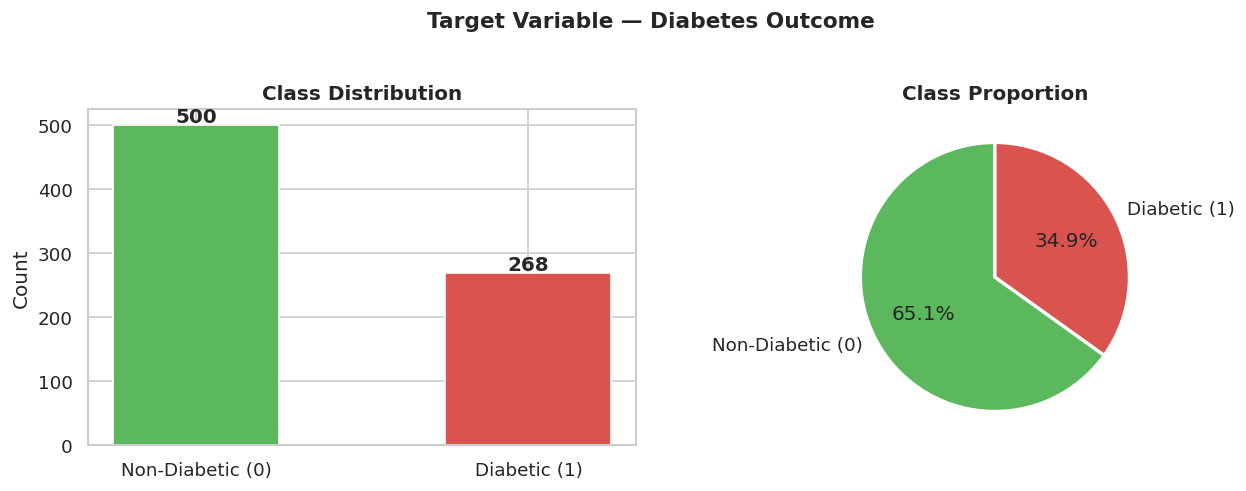

In [35]:
# 5.1 Target class distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

labels = ['Non-Diabetic (0)', 'Diabetic (1)']
counts = df_clean['Outcome'].value_counts().sort_index()
colors = ['#5cb85c', '#d9534f']

# Bar chart
axes[0].bar(labels, counts, color=colors, edgecolor='white', width=0.5)
for i, v in enumerate(counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontweight='bold')

plt.suptitle('Target Variable — Diabetes Outcome', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

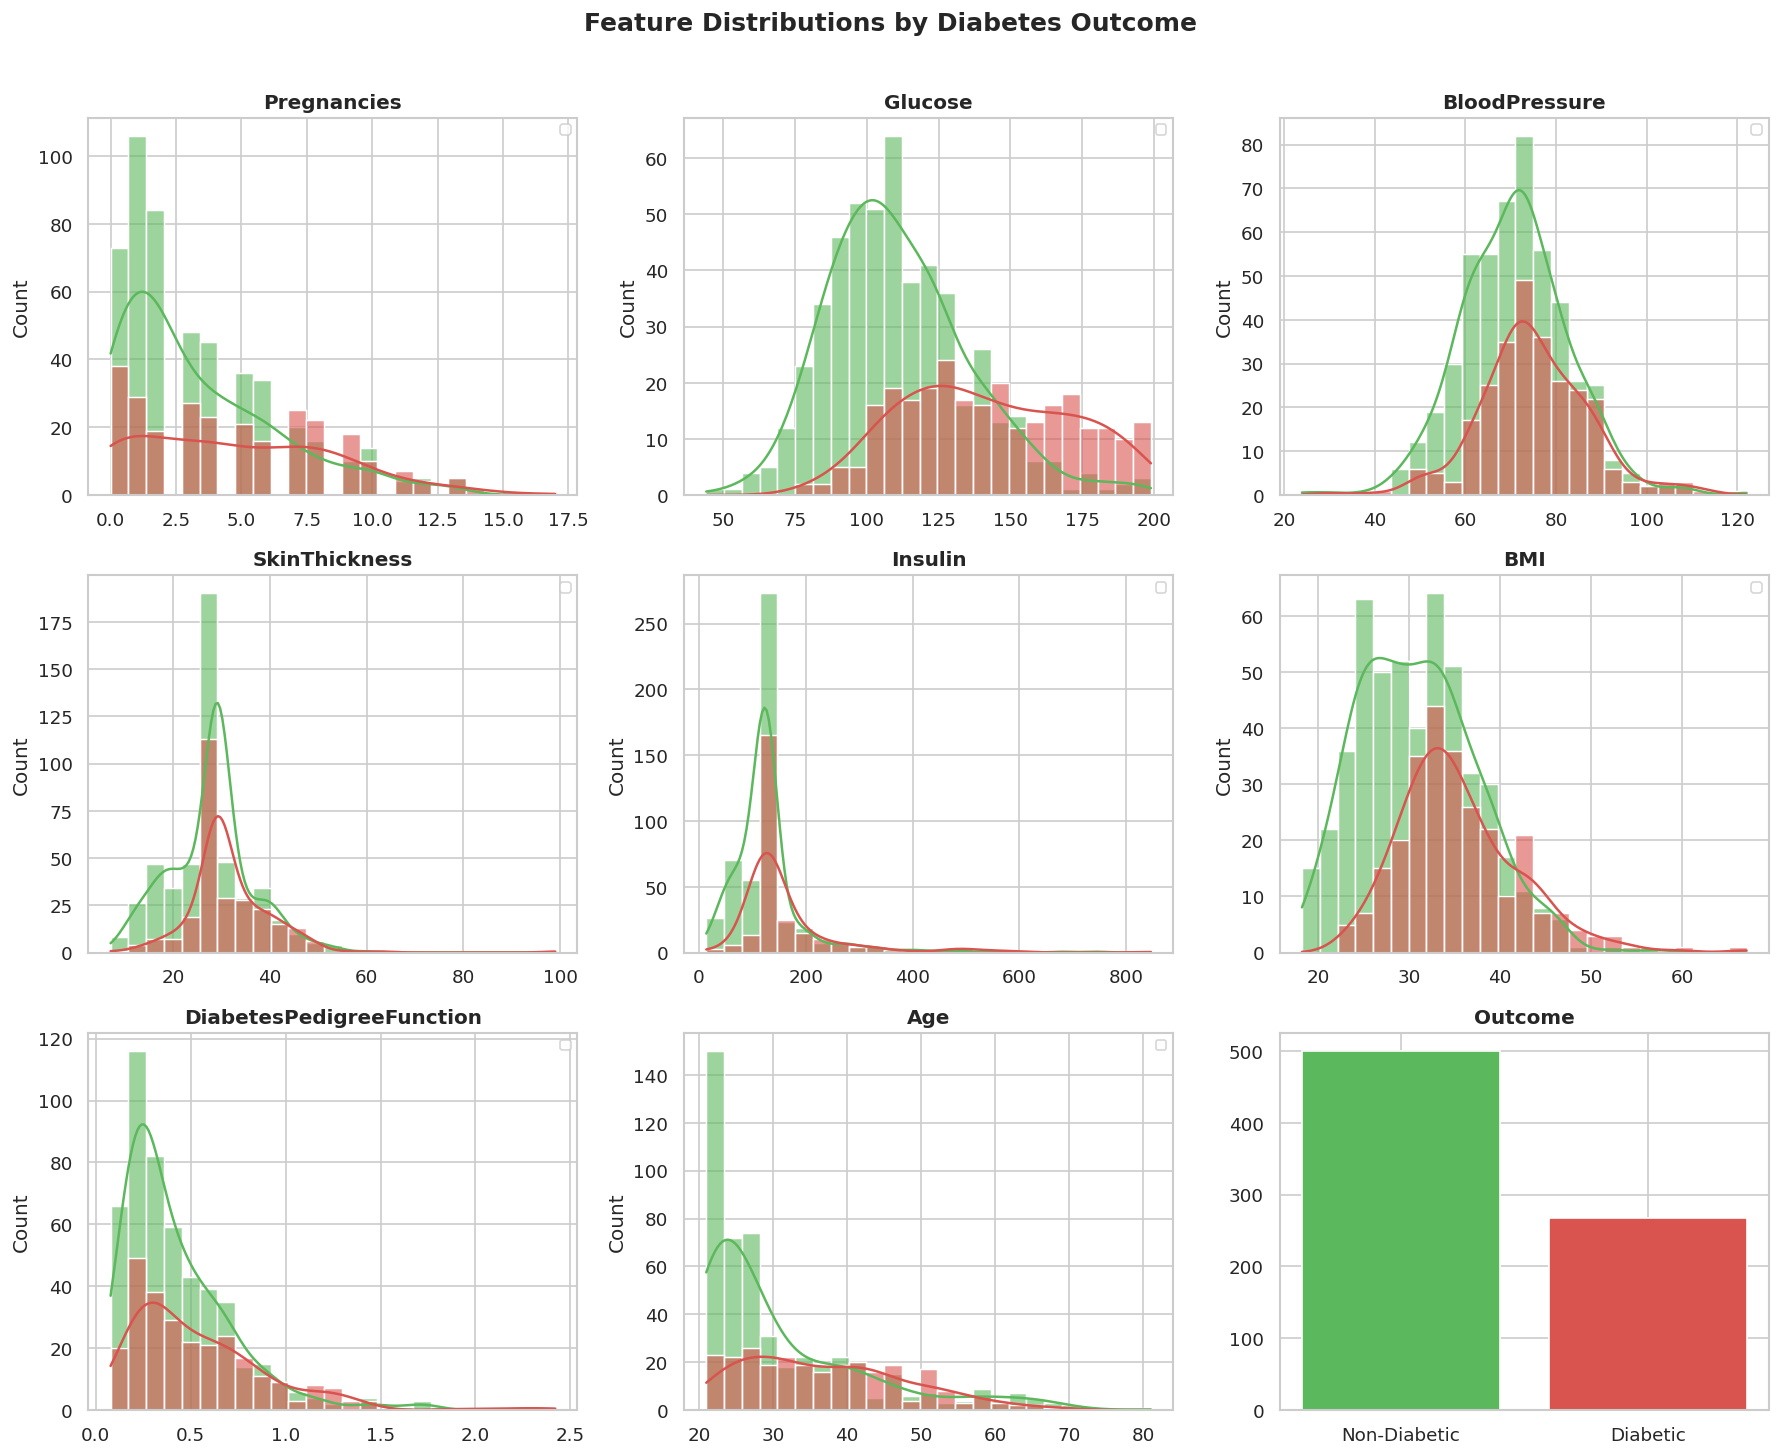

In [21]:
# 5.2 Distribution of all features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

all_cols = features + ['Outcome']
palette = {'Non-Diabetic': '#5cb85c', 'Diabetic': '#d9534f'}
hue_map = df_clean['Outcome'].map({0: 'Non-Diabetic', 1: 'Diabetic'})

for i, col in enumerate(all_cols):
    if col == 'Outcome':
        axes[i].bar(['Non-Diabetic', 'Diabetic'], counts, color=colors)
        axes[i].set_title('Outcome', fontweight='bold')
    else:
        sns.histplot(data=df_clean, x=col, hue=hue_map, ax=axes[i],
                     palette=palette, kde=True, alpha=0.6, bins=25)
        axes[i].set_title(col, fontweight='bold')
        axes[i].legend(title='', fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions by Diabetes Outcome', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

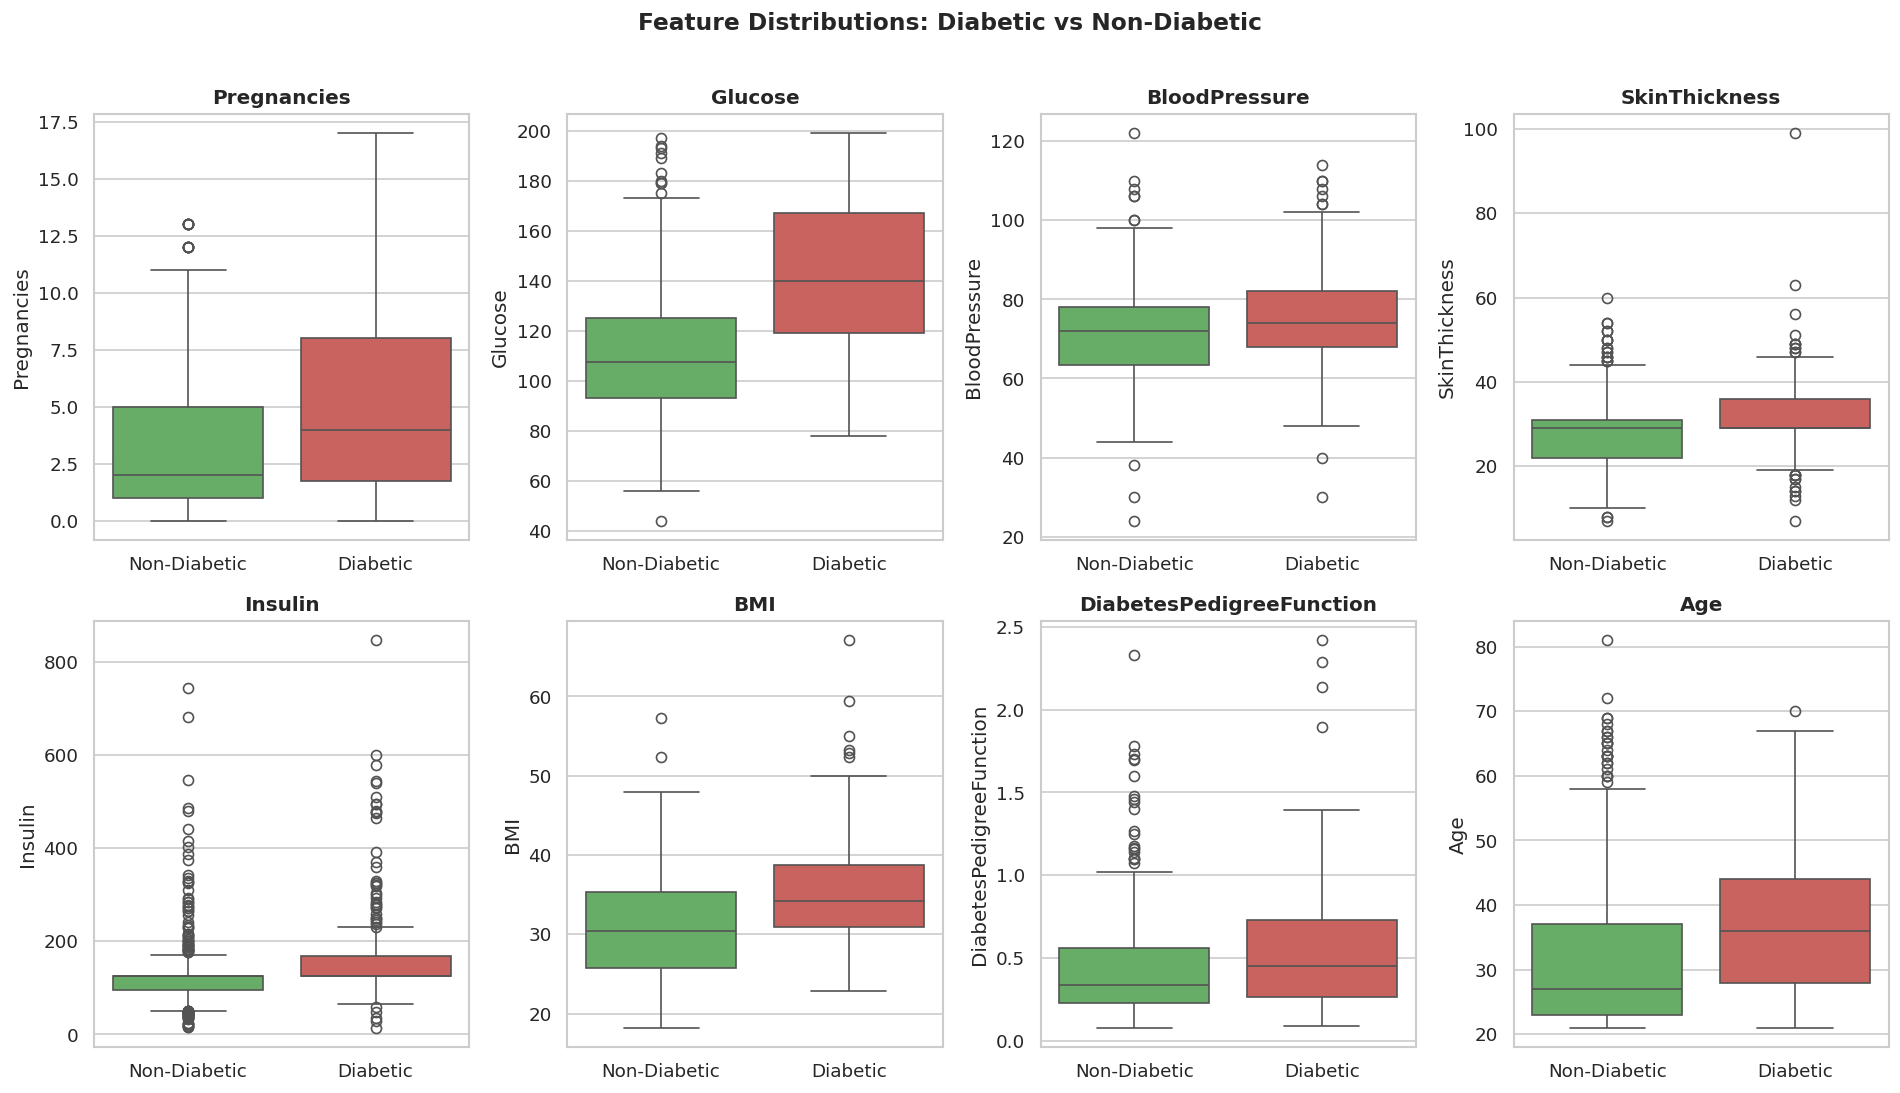

In [37]:
# 5.3 Boxplots — comparing diabetic vs non-diabetic
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df_clean, x='Outcome', y=col, ax=axes[i],
                palette={'0': '#5cb85c', '1': '#d9534f'})  # Changed keys to strings '0' and '1'
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xticklabels(['Non-Diabetic', 'Diabetic'])
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions: Diabetic vs Non-Diabetic', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

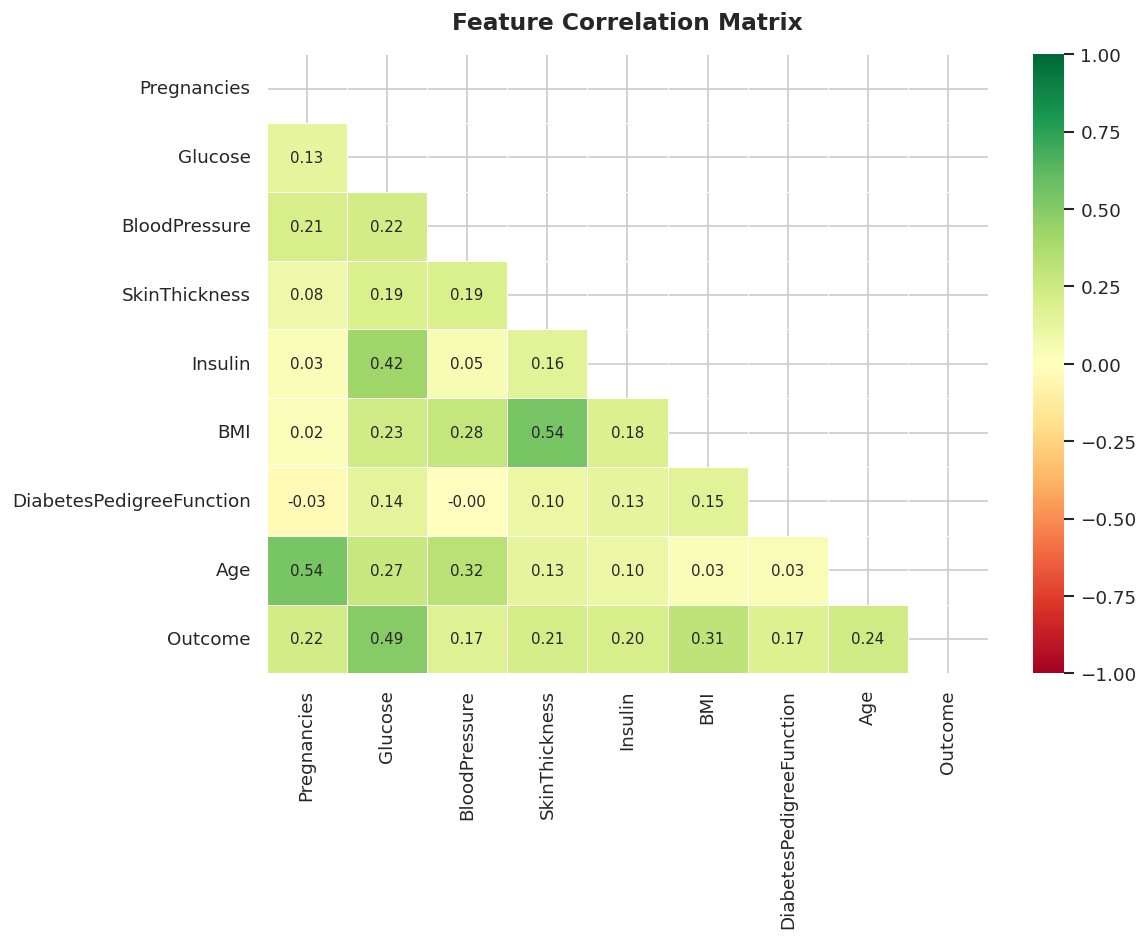


Correlation with Outcome (sorted):
Glucose                     0.493
BMI                         0.312
Age                         0.238
Pregnancies                 0.222
SkinThickness               0.215
Insulin                     0.204
DiabetesPedigreeFunction    0.174
BloodPressure               0.166
Name: Outcome, dtype: float64


In [38]:
# 5.4 Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))

corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Top correlations with Outcome
print('\nCorrelation with Outcome (sorted):')
print(corr['Outcome'].drop('Outcome').sort_values(ascending=False).round(3))

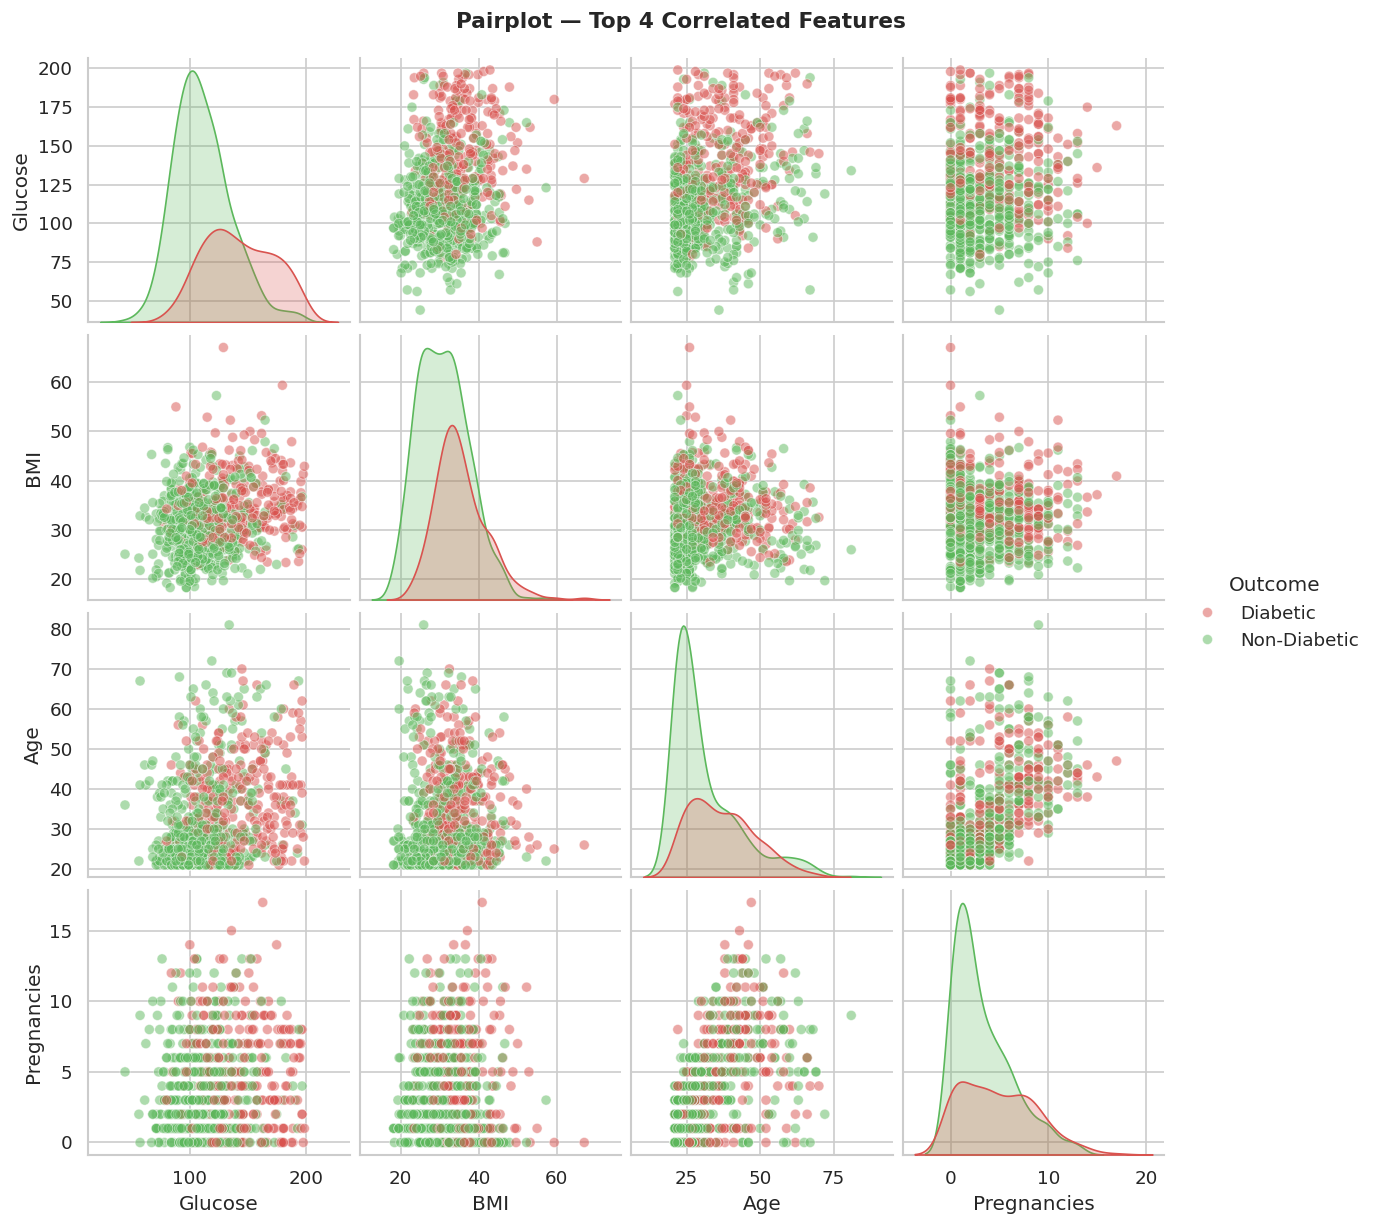

In [39]:
# 5.5 Pairplot for top correlated features
top_features = corr['Outcome'].drop('Outcome').abs().nlargest(4).index.tolist()
pairplot_df = df_clean[top_features + ['Outcome']].copy()
pairplot_df['Outcome'] = pairplot_df['Outcome'].map({0: 'Non-Diabetic', 1: 'Diabetic'})

g = sns.pairplot(pairplot_df, hue='Outcome',
                 palette={'Non-Diabetic': '#5cb85c', 'Diabetic': '#d9534f'},
                 diag_kind='kde', plot_kws={'alpha': 0.5})
g.fig.suptitle(f'Pairplot — Top 4 Correlated Features', y=1.02, fontsize=13, fontweight='bold')
plt.show()

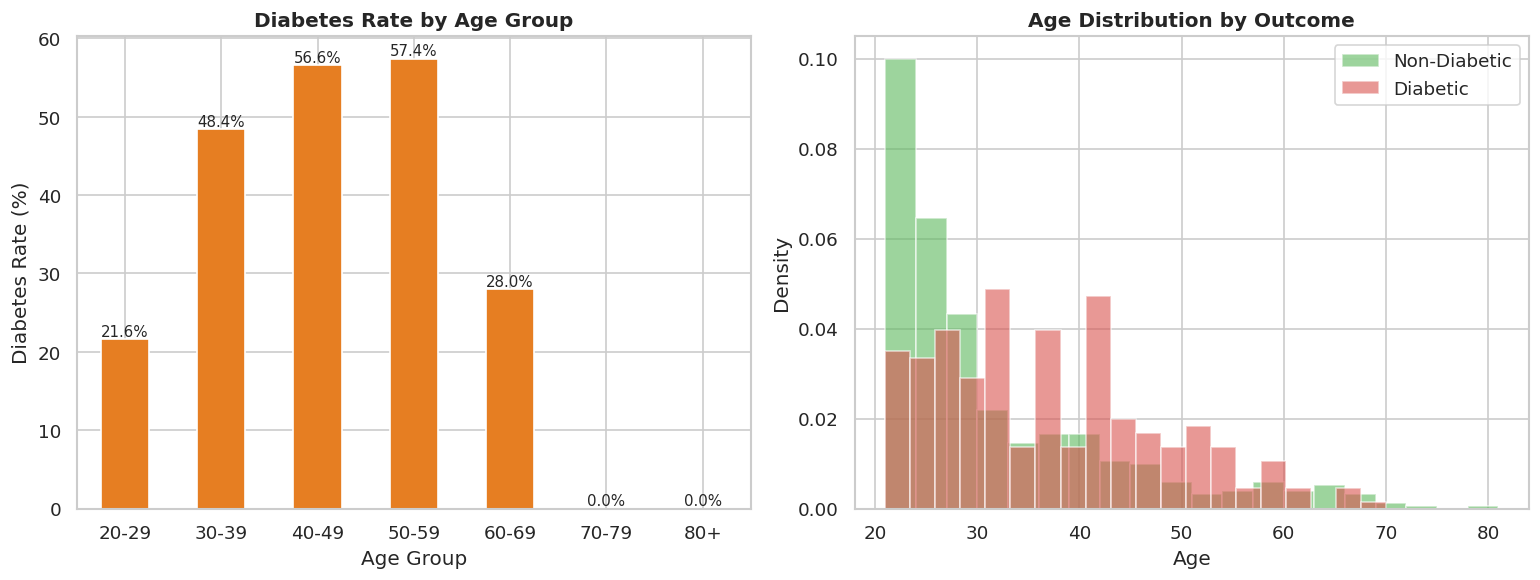

In [40]:
# 5.6 Age distribution analysis
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Age bins
bins = [20, 30, 40, 50, 60, 70, 80, 90]
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=bins,
                               labels=['20-29','30-39','40-49','50-59','60-69','70-79','80+'])

age_outcome = df_clean.groupby('AgeGroup', observed=True)['Outcome'].mean() * 100
age_outcome.plot(kind='bar', ax=axes[0], color='#e67e22', edgecolor='white')
axes[0].set_title('Diabetes Rate by Age Group', fontweight='bold')
axes[0].set_ylabel('Diabetes Rate (%)')
axes[0].set_xlabel('Age Group')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Age KDE
diabetic = df_clean[df_clean['Outcome'] == 1]['Age']
non_diabetic = df_clean[df_clean['Outcome'] == 0]['Age']
axes[1].hist(non_diabetic, bins=20, alpha=0.6, label='Non-Diabetic', color='#5cb85c', density=True)
axes[1].hist(diabetic, bins=20, alpha=0.6, label='Diabetic', color='#d9534f', density=True)
axes[1].set_title('Age Distribution by Outcome', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

df_clean.drop('AgeGroup', axis=1, inplace=True)

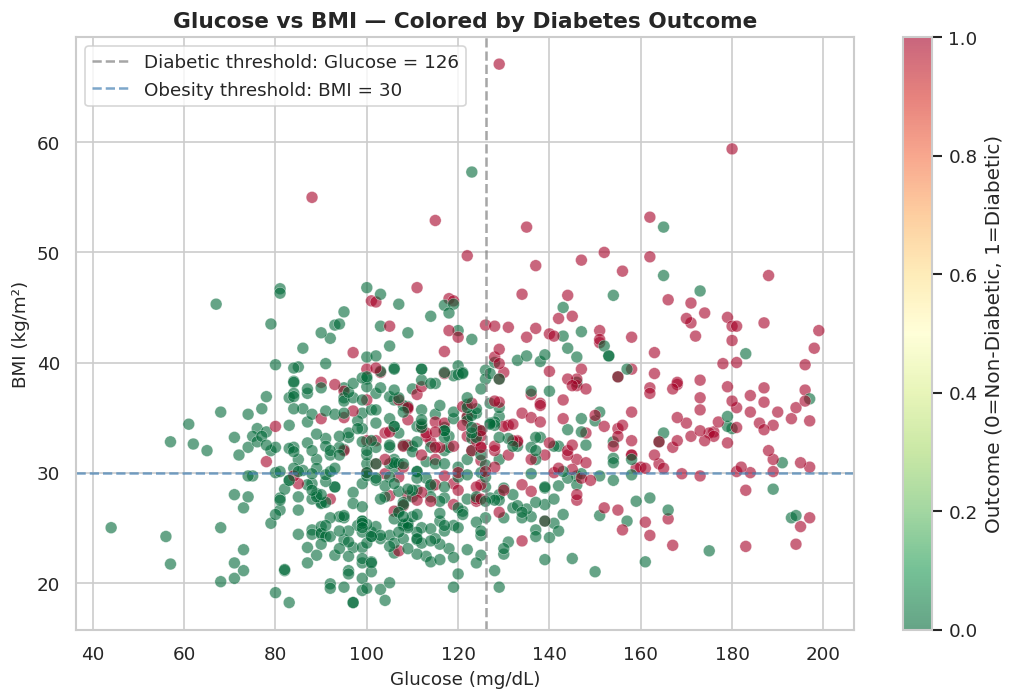

In [41]:
# 5.7 Glucose vs BMI scatter (key clinical indicators)
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    df_clean['Glucose'], df_clean['BMI'],
    c=df_clean['Outcome'], cmap='RdYlGn_r',
    alpha=0.6, edgecolors='white', linewidths=0.3, s=50
)
plt.colorbar(scatter, label='Outcome (0=Non-Diabetic, 1=Diabetic)')
ax.set_xlabel('Glucose (mg/dL)', fontsize=11)
ax.set_ylabel('BMI (kg/m²)', fontsize=11)
ax.set_title('Glucose vs BMI — Colored by Diabetes Outcome', fontweight='bold', fontsize=13)
ax.axvline(126, color='gray', linestyle='--', alpha=0.7, label='Diabetic threshold: Glucose = 126')
ax.axhline(30, color='steelblue', linestyle='--', alpha=0.7, label='Obesity threshold: BMI = 30')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Feature Engineering & Preprocessing <a id='6'></a>

In [15]:
# Prepare features and target
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')
print(f'Features: {list(X.columns)}')

Features shape: (768, 8)
Target shape:   (768,)
Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [16]:
# Train-test split (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set: {X_train.shape[0]} samples')
print(f'Test set:  {X_test.shape[0]} samples')
print(f'\nTrain class distribution:')
print(y_train.value_counts(normalize=True).round(3))
print(f'\nTest class distribution:')
print(y_test.value_counts(normalize=True).round(3))

Train set: 614 samples
Test set:  154 samples

Train class distribution:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64

Test class distribution:
Outcome
0    0.649
1    0.351
Name: proportion, dtype: float64


---
## 7. Decision Tree Model <a id='7'></a>

In [17]:
# 7.1 Baseline Decision Tree
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

y_pred_base = dt_base.predict(X_test)
base_acc = accuracy_score(y_test, y_pred_base)
print(f'Baseline Decision Tree Accuracy: {base_acc:.4f} ({base_acc*100:.2f}%)')
print(f'Tree Depth: {dt_base.get_depth()}')
print(f'Leaf Nodes: {dt_base.get_n_leaves()}')

Baseline Decision Tree Accuracy: 0.6818 (68.18%)
Tree Depth: 14
Leaf Nodes: 111


In [18]:
# 7.2 Hyperparameter tuning with GridSearchCV
param_grid = {
    'max_depth':        [3, 4, 5, 6, 7, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 5, 10],
    'criterion':         ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

print('Best Parameters:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV Accuracy: {grid_search.best_score_:.4f}')

Best Parameters:
  criterion: entropy
  max_depth: 3
  min_samples_leaf: 10
  min_samples_split: 2

Best CV Accuracy: 0.7574


In [19]:
# 7.3 Optimized Decision Tree
dt_best = grid_search.best_estimator_
y_pred = dt_best.predict(X_test)
y_prob = dt_best.predict_proba(X_test)[:, 1]

best_acc = accuracy_score(y_test, y_pred)
print(f'Optimized Decision Tree Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)')
print(f'Tree Depth: {dt_best.get_depth()}')
print(f'Leaf Nodes: {dt_best.get_n_leaves()}')

Optimized Decision Tree Accuracy: 0.6948 (69.48%)
Tree Depth: 3
Leaf Nodes: 8


In [20]:
# 7.4 Cross-validation scores
cv_scores = cross_val_score(dt_best, X, y, cv=10, scoring='accuracy')
print('10-Fold Cross-Validation Results:')
print(f'  Scores:   {cv_scores.round(4)}')
print(f'  Mean:     {cv_scores.mean():.4f}')
print(f'  Std Dev:  {cv_scores.std():.4f}')
print(f'  Range:    [{cv_scores.min():.4f}, {cv_scores.max():.4f}]')

10-Fold Cross-Validation Results:
  Scores:   [0.7273 0.7273 0.7273 0.6753 0.7143 0.7922 0.7532 0.8052 0.6974 0.7632]
  Mean:     0.7383
  Std Dev:  0.0385
  Range:    [0.6753, 0.8052]


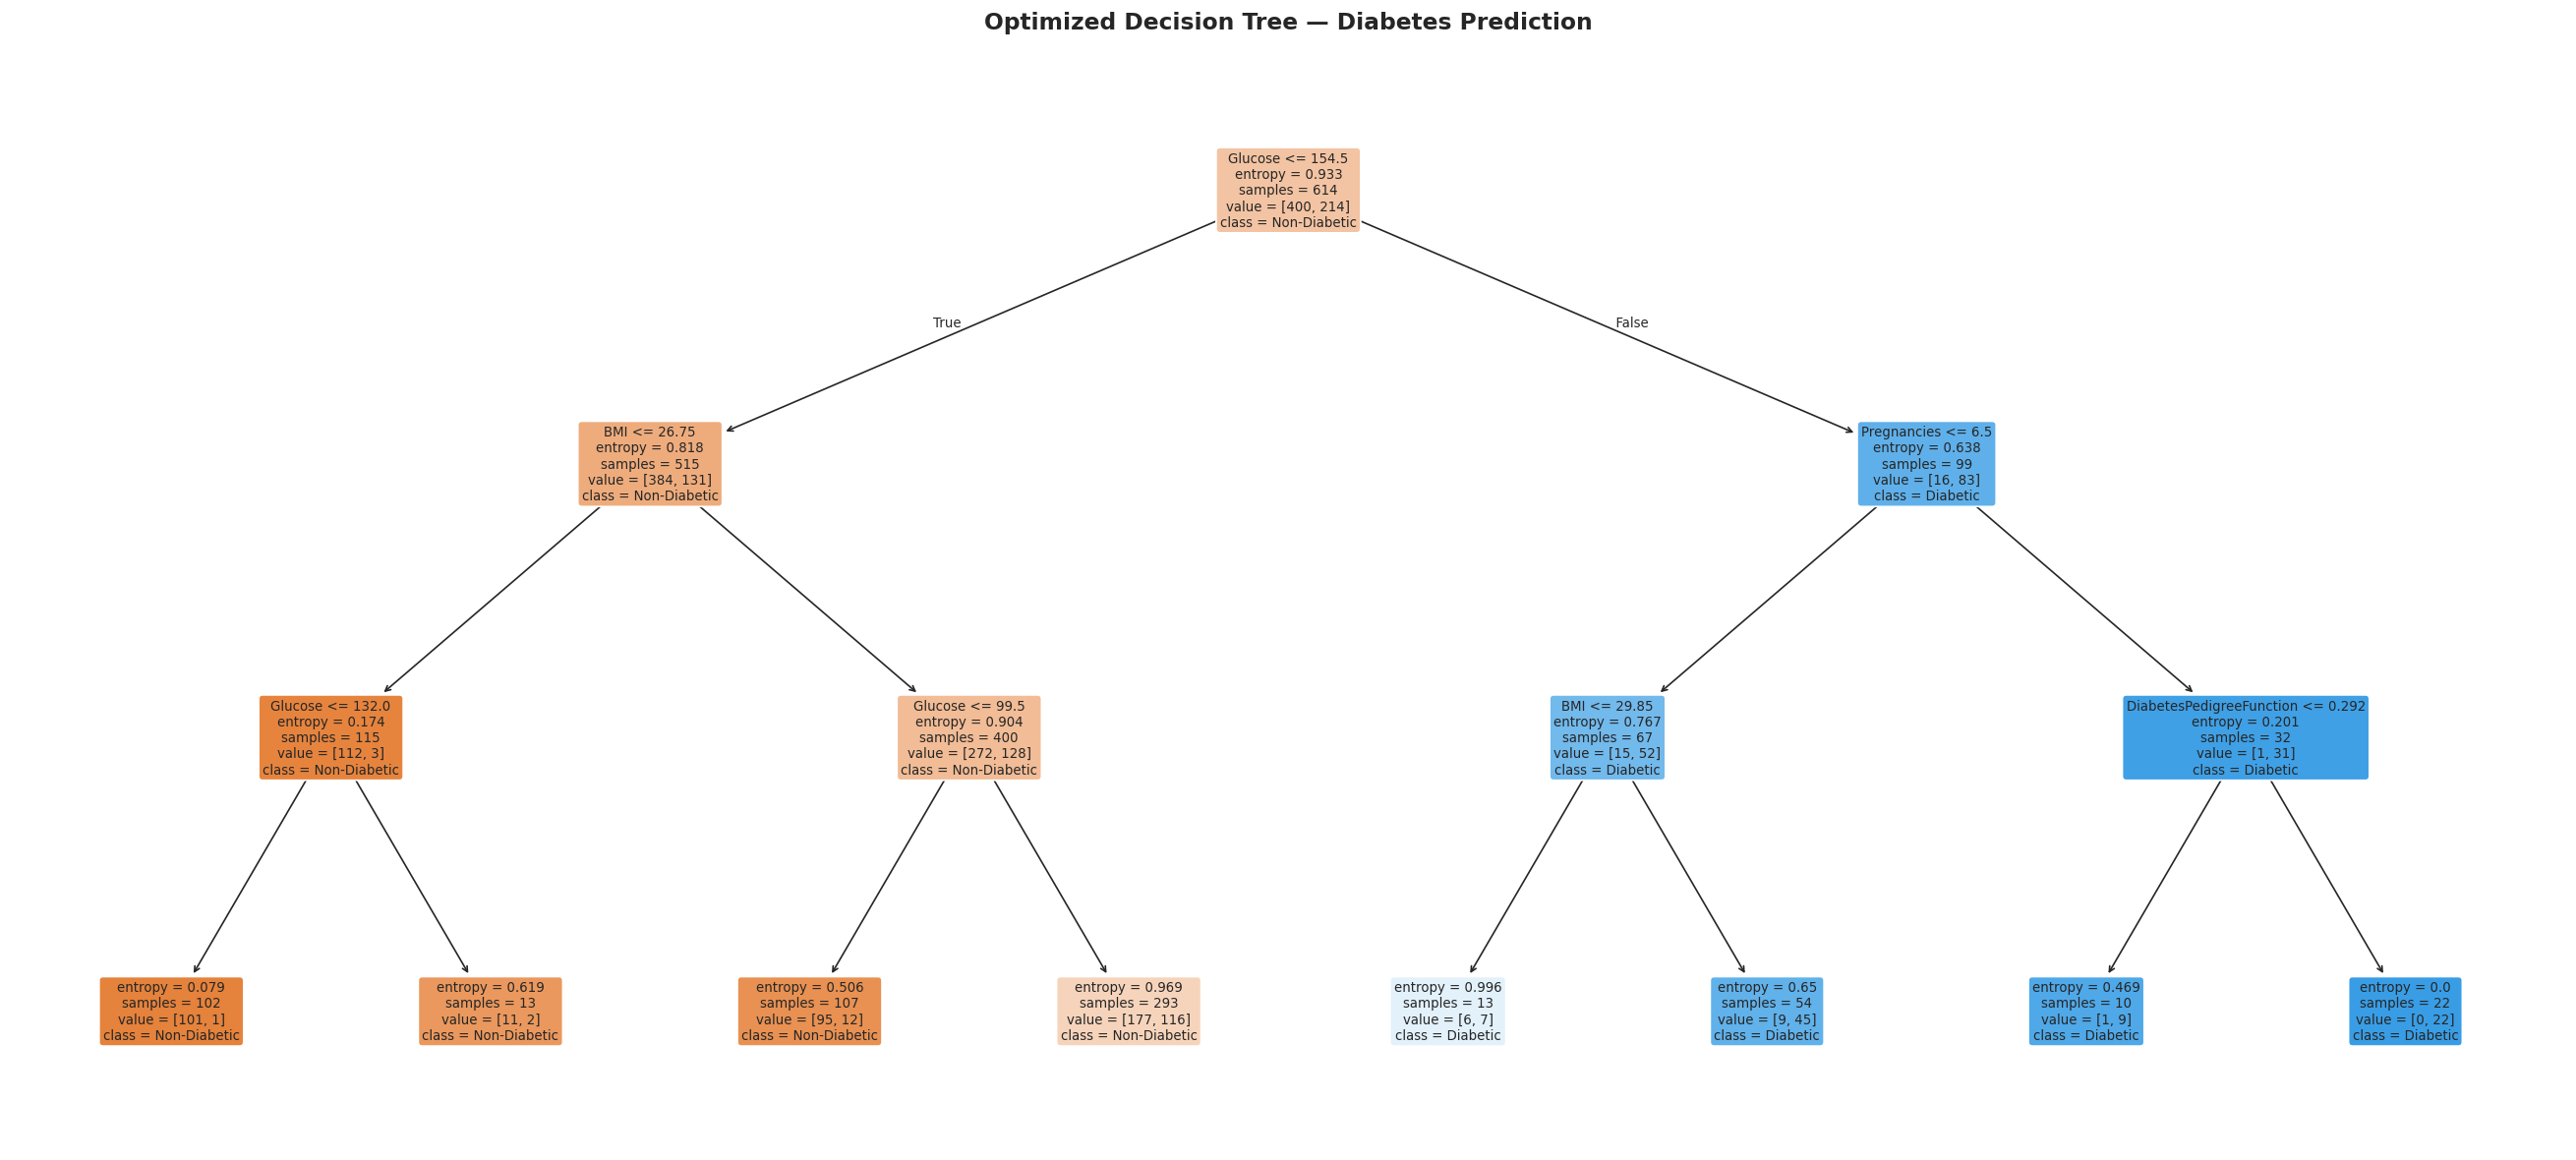

In [21]:
# 7.5 Visualize the Decision Tree
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_best,
    feature_names=list(X.columns),
    class_names=['Non-Diabetic', 'Diabetic'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title('Optimized Decision Tree — Diabetes Prediction', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## 8. Model Evaluation <a id='8'></a>

In [22]:
# 8.1 Classification report
print('Classification Report:')
print('='*60)
print(classification_report(y_test, y_pred, target_names=['Non-Diabetic', 'Diabetic']))

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.70      0.92      0.80       100
    Diabetic       0.65      0.28      0.39        54

    accuracy                           0.69       154
   macro avg       0.68      0.60      0.59       154
weighted avg       0.68      0.69      0.65       154



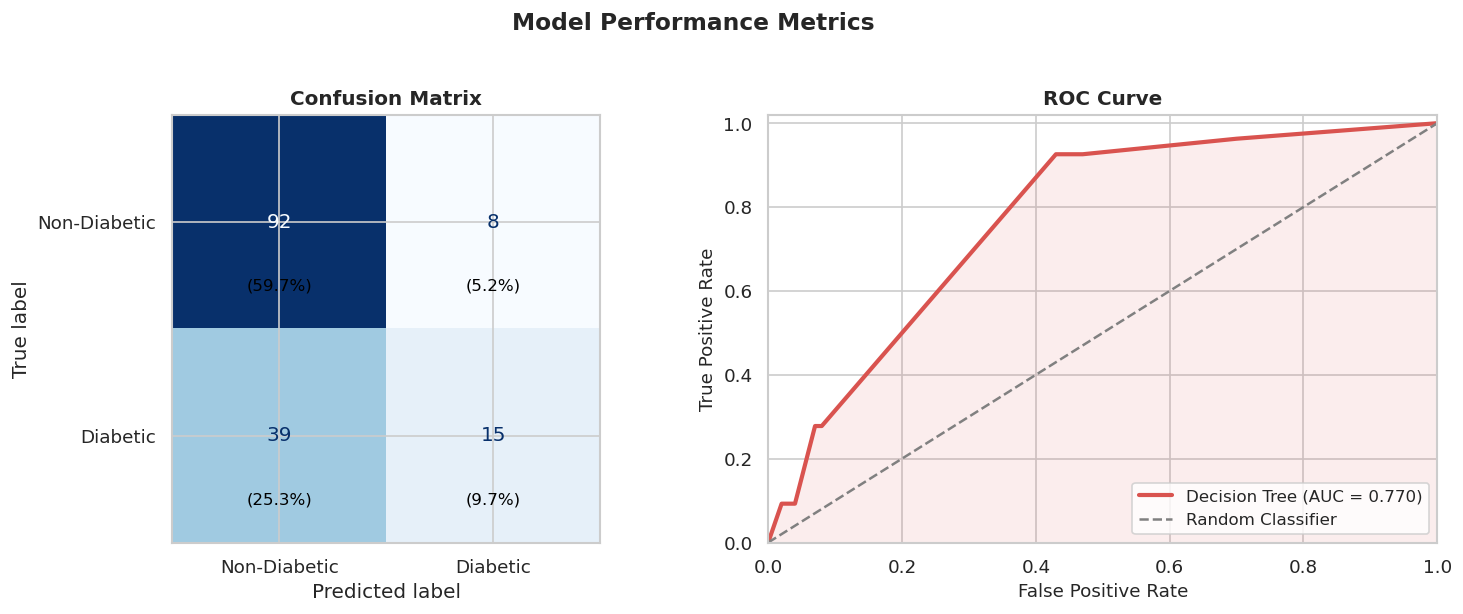

ROC-AUC Score: 0.7705


In [23]:
# 8.2 Confusion matrix + ROC curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Non-Diabetic', 'Diabetic'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=12)

# Add percentage annotations
total = cm.sum()
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / total * 100
        axes[0].text(j, i + 0.3, f'({pct:.1f}%)', ha='center', va='center',
                     fontsize=10, color='black')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

axes[1].plot(fpr, tpr, color='#d9534f', lw=2.5, label=f'Decision Tree (AUC = {auc:.3f})')
axes[1].plot([0,1], [0,1], color='gray', linestyle='--', lw=1.5, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#d9534f')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve', fontweight='bold', fontsize=12)
axes[1].legend(loc='lower right', fontsize=10)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle('Model Performance Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'ROC-AUC Score: {auc:.4f}')

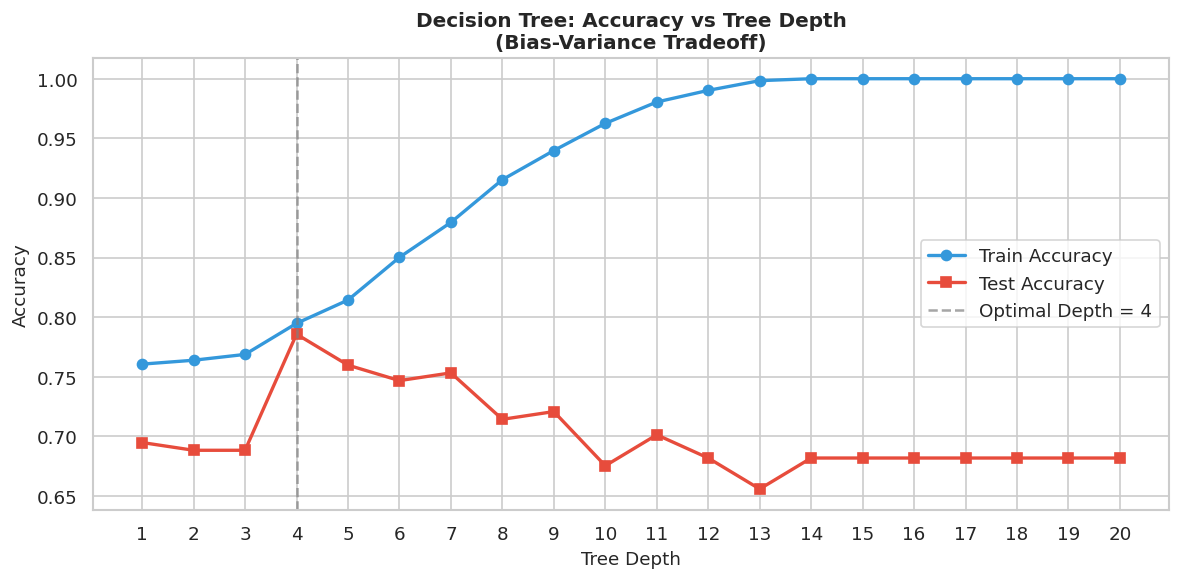

In [24]:
# 8.3 Depth vs Accuracy analysis
train_accs, test_accs = [], []
depths = range(1, 21)

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, dt.predict(X_train)))
    test_accs.append(accuracy_score(y_test, dt.predict(X_test)))

best_depth = depths[np.argmax(test_accs)]

plt.figure(figsize=(10, 5))
plt.plot(depths, train_accs, 'o-', color='#3498db', label='Train Accuracy', lw=2)
plt.plot(depths, test_accs, 's-', color='#e74c3c', label='Test Accuracy', lw=2)
plt.axvline(best_depth, color='gray', linestyle='--', alpha=0.7,
            label=f'Optimal Depth = {best_depth}')
plt.xlabel('Tree Depth', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.title('Decision Tree: Accuracy vs Tree Depth\n(Bias-Variance Tradeoff)', fontweight='bold')
plt.legend()
plt.xticks(depths)
plt.tight_layout()
plt.show()

---
## 9. Feature Importance <a id='9'></a>

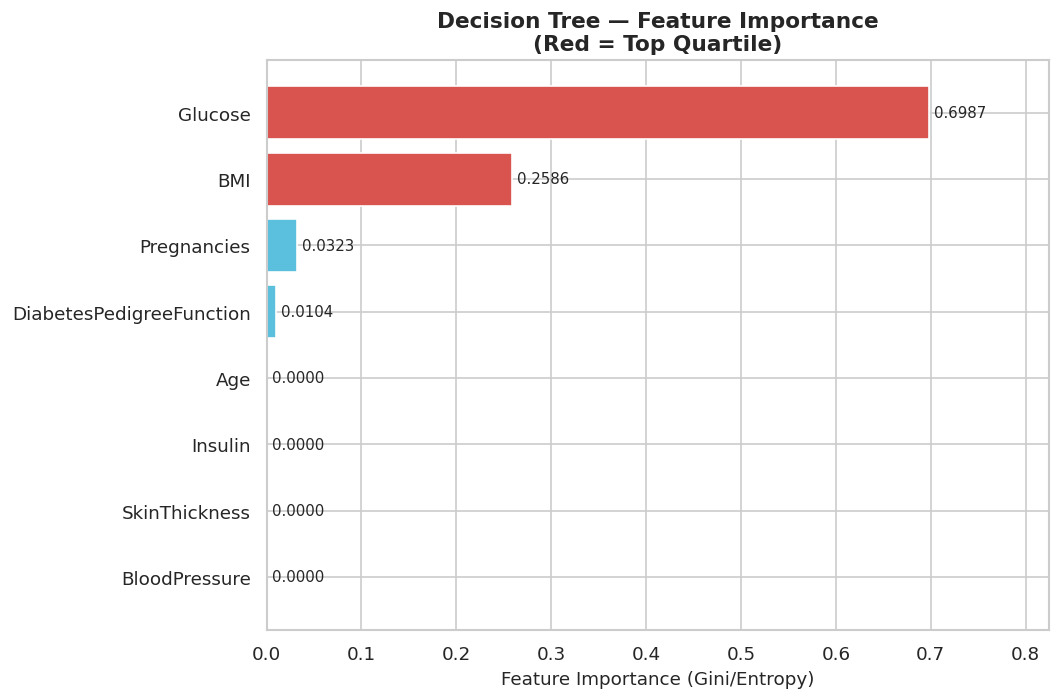


Feature Importance Ranking:
  1. Glucose                        0.6987 (69.87%)
  2. BMI                            0.2586 (25.86%)
  3. Pregnancies                    0.0323 (3.23%)
  4. DiabetesPedigreeFunction       0.0104 (1.04%)
  5. BloodPressure                  0.0000 (0.00%)
  6. SkinThickness                  0.0000 (0.00%)
  7. Insulin                        0.0000 (0.00%)
  8. Age                            0.0000 (0.00%)


In [25]:
# Feature importance from Decision Tree
importances = pd.Series(dt_best.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

colors_imp = ['#d9534f' if imp >= importances.quantile(0.75) else '#5bc0de' for imp in importances]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importances.index, importances.values, color=colors_imp, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_xlabel('Feature Importance (Gini/Entropy)', fontsize=11)
ax.set_title('Decision Tree — Feature Importance\n(Red = Top Quartile)', fontweight='bold', fontsize=13)
ax.set_xlim(0, importances.max() * 1.18)
plt.tight_layout()
plt.show()

print('\nFeature Importance Ranking:')
for rank, (feat, imp) in enumerate(importances.sort_values(ascending=False).items(), 1):
    print(f'  {rank}. {feat:<30} {imp:.4f} ({imp*100:.2f}%)')

---
## 10. Key Insights & Summary <a id='10'></a>

In [26]:
# Summary dashboard
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print('='*60)
print('         FINAL MODEL SUMMARY')
print('='*60)
print(f'  Dataset       : Pima Indians Diabetes')
print(f'  Total Samples : {len(df_clean)}')
print(f'  Features Used : {X.shape[1]}')
print(f'  Train/Test    : {len(X_train)}/{len(X_test)} (80/20 stratified)')
print('─'*60)
print(f'  Model         : Decision Tree (Optimized)')
print(f'  Best Params   : {grid_search.best_params_}')
print('─'*60)
print(f'  Accuracy      : {best_acc*100:.2f}%')
print(f'  Precision     : {precision*100:.2f}%')
print(f'  Recall        : {recall*100:.2f}%')
print(f'  F1-Score      : {f1*100:.2f}%')
print(f'  ROC-AUC       : {auc:.4f}')
print(f'  CV Accuracy   : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')
print('─'*60)
top_feat = importances.sort_values(ascending=False)
print(f'  Top Feature   : {top_feat.index[0]} ({top_feat.iloc[0]*100:.1f}% importance)')
print(f'  2nd Feature   : {top_feat.index[1]} ({top_feat.iloc[1]*100:.1f}% importance)')
print('='*60)

         FINAL MODEL SUMMARY
  Dataset       : Pima Indians Diabetes
  Total Samples : 768
  Features Used : 8
  Train/Test    : 614/154 (80/20 stratified)
────────────────────────────────────────────────────────────
  Model         : Decision Tree (Optimized)
  Best Params   : {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 2}
────────────────────────────────────────────────────────────
  Accuracy      : 69.48%
  Precision     : 65.22%
  Recall        : 27.78%
  F1-Score      : 38.96%
  ROC-AUC       : 0.7705
  CV Accuracy   : 73.83% ± 3.85%
────────────────────────────────────────────────────────────
  Top Feature   : Glucose (69.9% importance)
  2nd Feature   : BMI (25.9% importance)
